# Dynamic Treatment Regime (DTR) Examples from Chapter 8

This notebook implements and explores examples from Chapter 8 of the Causal Reinforcement Learning book, focusing on Dynamic Treatment Regimes (DTRs). Specifically, we'll implement examples 8.21, 8.24, 8.25, and 8.30, which demonstrate different policy evaluation techniques in causal reinforcement learning.

## Introduction to Dynamic Treatment Regimes

A Dynamic Treatment Regime (DTR) is a sequence of decision rules for treating a medical condition that adapts over time based on the evolving state of the patient. In healthcare, a typical patient is often treated at multiple stages, where the physician repeatedly adapts each treatment based on the patient's time-varying state.

In our examples, we'll work with a 2-stage DTR for managing alcohol-dependent patients:
- Stage 1: Based on the patient's initial condition (S₁), the physician chooses between behavioral therapy (X₁=0) or medication (X₁=1)
- Stage 2: After observing the patient's response (S₂), the physician decides whether to continue the initial treatment (X₂=0) or switch to a more intensive combined therapy (X₂=1)
- The goal is to maximize the primary outcome (Y) measuring days of abstinence over 12 months

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import seaborn as sns

# Import the DTR environment from causal_gym
from causal_gym.envs.dtr_example import DTRExampleSCM, DTRExamplePCH

## DTR Example Setup

Let's explore the DTR environment that's based on Example 8.6 from the textbook. The formal definition of the environment is an SCM $M^*_{DTR}$ given by:

$$M^*_{DTR} = \langle U = \\{U, U_1, \ldots, U_4\\}, V = \\{S_1, S_2, X_1, X_2, Y\\}, F_{DTR}, P(U) \rangle$$

where the underlying causal mechanisms $F_{DTR}$ are defined as:

$$
F_{DTR} = 
\begin{cases}
S_1 \gets I\\{U_3 > 0\\}, \\
X_1 \gets I\\{3S_1 + a_1U + U_1 > 0\\}, \\
S_2 \gets I\\{0.1 + 0.1S_1 + 0.1X_1 + U_4 > 0\\}, \\
X_2 \gets I\\{3S_2 + a_2U + U_2 > 0\\}, \\
Y \gets I\\{3U - 3S_1 - 3X_1 - 3S_1X_1 + 3X_2 - 3S_2X_2 + 3X_1X_2 > 0\\}
\end{cases}
$$

The exogenous variables include:
- $U \\sim Unif(0, 1)$ - Represents unmeasured patient characteristics
- $U_i \\sim Logistic(0, 1)$ for $i = 1, ..., 4$ - Independent noise variables

The coefficients $a_1, a_2$ determine whether the No Unmeasured Confounder (NUC) condition holds:
- When $a_1 = a_2 = 0$: NUC holds (no confounding)
- When either coefficient is non-zero: NUC doesn't hold (confounding exists)

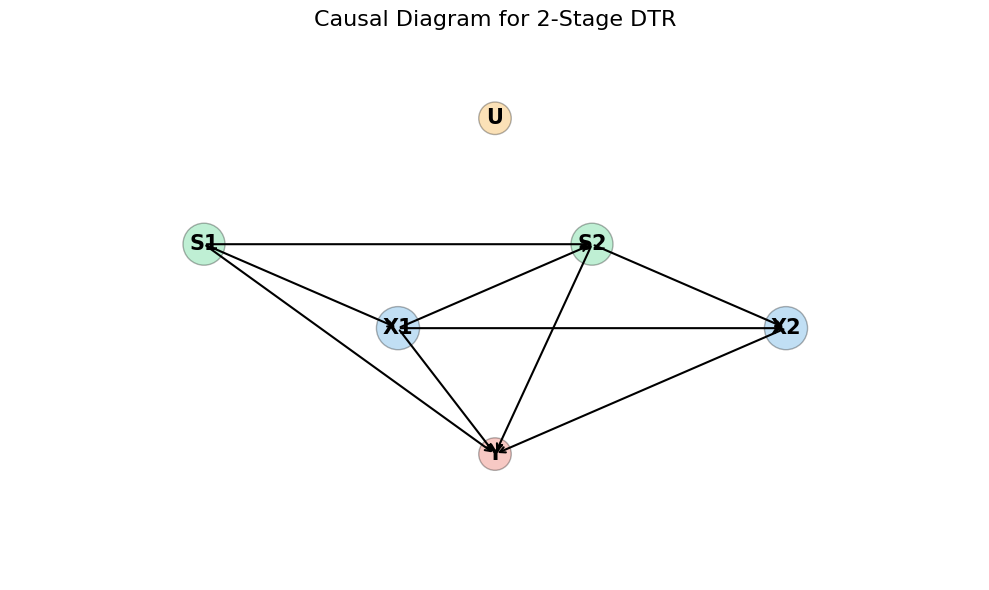

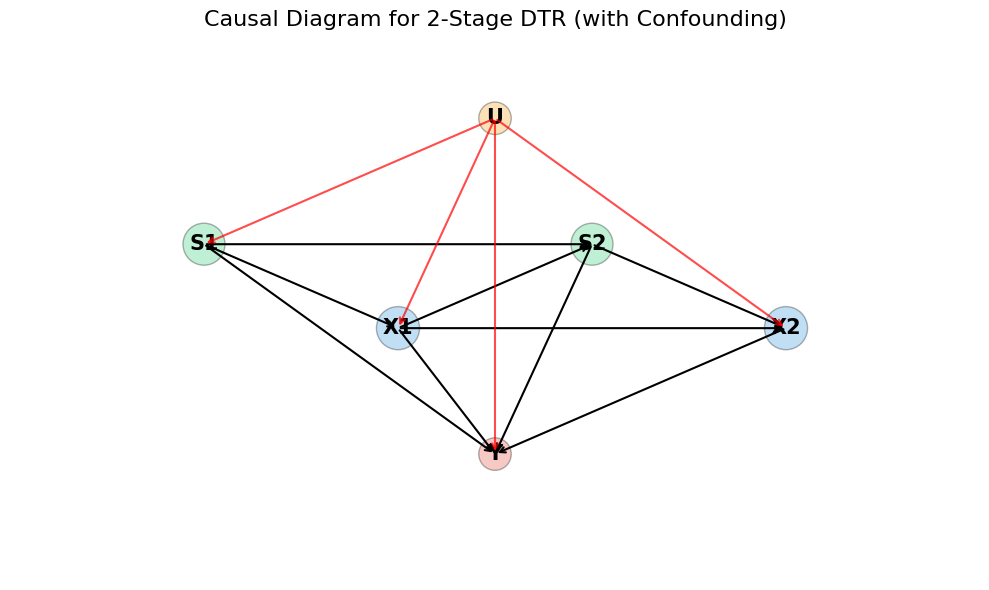

In [3]:
# Helper function to visualize the causal diagram of the DTR environment
def plot_dtr_causal_diagram(confounded=False):
    # Create a figure
    plt.figure(figsize=(10, 6))
    
    # Node positions
    node_positions = {
        'S1': (0.2, 0.8),
        'X1': (0.4, 0.6),
        'S2': (0.6, 0.8),
        'X2': (0.8, 0.6),
        'Y': (0.5, 0.3),
        'U': (0.5, 1.1)
    }
    
    # Draw nodes
    for node, pos in node_positions.items():
        if node == 'U':
            color = '#f39c12' # Yellow for unobserved
            plt.text(pos[0], pos[1], node, ha='center', va='center', fontsize=15,
                    fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
        else:
            if node.startswith('X'):
                color = '#3498db' # Blue for actions
            elif node == 'Y':
                color = '#e74c3c' # Red for outcome
            else:
                color = '#2ecc71' # Green for states
            plt.text(pos[0], pos[1], node, ha='center', va='center', fontsize=15,
                    fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    
    # Draw edges
    edges = [
        ('S1', 'X1'),
        ('S1', 'S2'),
        ('S1', 'Y'),
        ('X1', 'S2'),
        ('X1', 'Y'),
        ('S2', 'X2'),
        ('S2', 'Y'),
        ('X2', 'Y'),
        ('X1', 'X2'),
    ]
    
    # Draw directed edges
    for src, dst in edges:
        plt.annotate("", xy=node_positions[dst], xytext=node_positions[src],
                   arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
    
    # Draw confounding edges if specified
    if confounded:
        # Add confounding edges from U
        for node in ['S1', 'X1', 'X2', 'Y']:
            plt.annotate("", xy=node_positions[node], xytext=node_positions['U'],
                       arrowprops=dict(arrowstyle="->", color="red", lw=1.5, alpha=0.7))
    
    plt.title("Causal Diagram for 2-Stage DTR" + (" (with Confounding)" if confounded else ""), fontsize=16)
    plt.xlim(0, 1)
    plt.ylim(0, 1.3)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize the causal diagram without and with confounding
plot_dtr_causal_diagram(confounded=False)
plot_dtr_causal_diagram(confounded=True)

## Example 8.21: Identification under NUC

Example 8.21 demonstrates that when the No Unmeasured Confounder (NUC) condition holds, we can identify the effect of a policy from observational data. Let's set up the environment without confounding ($a_1 = a_2 = 0$) and perform policy evaluation using Inverse Probability Weighting (IPW).

The policy space in this example is defined as:
$$P = {\langle X_1, \\{S_1\\} \rangle, \langle X_2, \\{S_1, X_1, S_2\\} \rangle\\}$$

We'll evaluate a policy $p = (X_1 \gets 0, X_2 \gets 1)$ that prescribes behavioral therapy (X₁=0) followed by intensive combined therapy (X₂=1).

### Collecting Observational Data

First, we'll collect observational data by running the environment with the default behavioral policy
   

In [4]:
from utilities import collect_observational_data_dtr
# Set up DTR environment without confounding
env = DTRExamplePCH(a1=0, a2=0)

# Number of episodes for data collection
NUM_EPISODES = 10000

# Collect observational data
obs_data = collect_observational_data_dtr(env, NUM_EPISODES)

# Display a sample of the data
print(f"Collected {len(obs_data)} trajectories of observational data")
obs_data.head()

Collected 10000 trajectories of observational data


,S1,X1,S2,X2,Y
0,0,0,0,1,1
1,0,1,1,1,1
2,1,1,1,1,0
3,0,1,0,1,1
4,0,1,1,1,1


In [5]:
# Calculate the joint probability distribution P(S1, X1, S2, X2, Y)
def calculate_joint_distribution(data):
    total_count = len(data)
    joint_distribution = {}
    
    # Group by all variables and count occurrences
    counts = data.groupby(['S1', 'X1', 'S2', 'X2', 'Y']).size().reset_index(name='Count')
    
    # Calculate probabilities
    for _, row in counts.iterrows():
        key = (row['S1'], row['X1'], row['S2'], row['X2'], row['Y'])
        joint_distribution[key] = row['Count'] / total_count
    
    return joint_distribution

# Calculate joint distribution
joint_dist = calculate_joint_distribution(obs_data)

# Display the distribution in a more readable format
joint_dist_df = pd.DataFrame([
    {'S1': s1, 'X1': x1, 'S2': s2, 'X2': x2, 'Y': y, 'Probability': prob}
    for (s1, x1, s2, x2, y), prob in joint_dist.items()
])

# Sort by variables for better readability
joint_dist_df = joint_dist_df.sort_values(['S1', 'X1', 'S2', 'X2', 'Y']).reset_index(drop=True)

# Display the distribution
print("Joint Distribution P(S1, X1, S2, X2, Y):")
print("-----------------------------------")
pd.set_option('display.precision', 4)
joint_dist_df

Joint Distribution P(S1, X1, S2, X2, Y):
-----------------------------------


,S1,X1,S2,X2,Y,Probability
0,0,0,0,0,1,0.0598
1,0,0,0,1,1,0.0625
2,0,0,1,0,1,0.0066
3,0,0,1,1,1,0.1242
4,0,1,0,0,0,0.0540
5,0,1,0,1,1,0.0589
6,0,1,1,0,0,0.0063
7,0,1,1,1,1,0.1308
8,1,0,0,0,0,0.0041
9,1,0,0,1,1,0.0058


### Computing Conditional Probabilities

For IPW evaluation, we need to compute the conditional probabilities $P(X_1|S_1)$ and $P(X_2|S_1,X_1,S_2)$, which represent the behavior policy probabilities
   

In [6]:
from utilities import compute_propensity_scores

# Calculate propensity scores
p_x1_given_s1, p_x2_given_s1_x1_s2 = compute_propensity_scores(obs_data)

# Display P(X1|S1)
print("P(X1|S1):")
for (s1, x1), prob in p_x1_given_s1.items():
    print(f"P(X1={x1}|S1={s1}) = {prob:.4f}")

print("P(X2|S1,X1,S2) (showing a few examples):")
# Show a few examples of P(X2|S1,X1,S2)
for (s1, x1, s2, x2), prob in list(p_x2_given_s1_x1_s2.items())[:8]:
    print(f"P(X2={x2}|S1={s1},X1={x1},S2={s2}) = {prob:.4f}")

P(X1|S1):
P(X1=0|S1=0) = 0.5031
P(X1=1|S1=0) = 0.4969
P(X1=0|S1=1) = 0.0473
P(X1=1|S1=1) = 0.9527
P(X2|S1,X1,S2) (showing a few examples):
P(X2=0|S1=0,X1=0,S2=0) = 0.4890
P(X2=1|S1=0,X1=0,S2=0) = 0.5110
P(X2=0|S1=0,X1=0,S2=1) = 0.0505
P(X2=1|S1=0,X1=0,S2=1) = 0.9495
P(X2=0|S1=0,X1=1,S2=0) = 0.4783
P(X2=1|S1=0,X1=1,S2=0) = 0.5217
P(X2=0|S1=0,X1=1,S2=1) = 0.0460
P(X2=1|S1=0,X1=1,S2=1) = 0.9540


### Inverse Probability Weighting (IPW) Evaluation

Now we'll implement the IPW method to evaluate our target policy $p = (X_1 \gets 0, X_2 \gets 1)$. The IPW formula from Theorem 8.2.1 is:

$$\mathbb{E}_p[R(Y)] = \sum_{\bar{x}_H, \bar{s}_H} \mathbb{E}[R(Y) | \bar{x}_H, \bar{s}_H] P(\bar{x}_H, \bar{s}_H) \prod_{i=1}^{H} \frac{p_i(x_i|s_i)}{P(x_i|\bar{x}_{i-1}, \bar{s}_i)}$$

For our 2-stage DTR and deterministic policy, this simplifies to:

$$\mathbb{E}_{X_1 \gets 0, X_2 \gets 1}[Y] = \sum_{s_1, x_1, s_2, x_2} \mathbb{E}[Y | s_1, x_1, s_2, x_2] P(s_1, x_1, s_2, x_2) \frac{I\\{x_1 = 0\\}}{P(x_1|s_1)} \frac{I\\{x_2 = 1\\}}{P(x_2|s_1, x_1, s_2)}$$
   

In [1]:
from utilities import ipw_policy_evaluation

ipw_result = ipw_policy_evaluation(joint_dist_df, policy1=0, policy2=1, propensity_x1=p_x1_given_s1, propensity_x2=p_x2_given_s1_x1_s2)

print(f"IPW Estimate for policy (X₁←0, X₂←1): {ipw_result:.4f}")

NameError: name 'joint_dist_df' is not defined

### Direct Intervention for Verification

To verify our IPW estimate, let's directly intervene in the environment with our target policy and measure the outcome
   

In [8]:
# Function to directly evaluate a policy by intervention
def direct_policy_evaluation(env, policy, num_episodes=10000):
    rewards = []
    
    for _ in tqdm(range(num_episodes), desc="Direct policy evaluation"):
        # Reset the environment
        s1, _ = env.env.reset()
        
        # First stage: apply policy for X1
        x1 = policy(s1)
        s2, _, _, _, _ = env.do(x1)
        
        # Second stage: apply policy for X2
        x2 = policy(s1, x1, s2)
        _, y, _, _, _ = env.do(x2)
        
        rewards.append(y)
    
    return np.mean(rewards)

# Evaluate the policy directly
direct_result = direct_policy_evaluation(env, policy_x1_0_x2_1)

print(f"Direct Evaluation for policy (X₁←0, X₂←1): {direct_result:.4f}")
print(f"IPW Estimate: {ipw_result:.4f}")
print(f"Difference: {abs(direct_result - ipw_result):.4f}")

Direct policy evaluation: 100%|██████████| 10000/10000 [00:00<00:00, 54560.97it/s]

Direct Evaluation for policy (X₁←0, X₂←1): 0.7244
IPW Estimate: 0.7124
Difference: 0.0120


### Analysis of Example 8.21

The results demonstrate that when the NUC condition holds (i.e., when $a_1 = a_2 = 0$), the IPW estimate closely matches the true policy value obtained through direct intervention. This confirms Theorem 8.2.1, which states that under the NUC condition, we can identify the effect of a policy from observational data using the IPW method.

Next, let's implement Dynamic Programming (DP) evaluation as an alternative approach

## Examples 8.24 and 8.25: Policy Evaluation with Sequential Backdoor Criterion

Now, let's implement a different environment that satisfies the sequential backdoor criterion but doesn't satisfy the NUC condition. This corresponds to Examples 8.24 and 8.25 in the textbook.

The SCM for this environment is:

$$M^* = \langle U = {U_i\\}_{i=1}^5, V = {S_1, S_2, X_1, X_2, Y\\}, F, P(U) \rangle$$

with structural functions:

$$
F = 
\begin{cases}
S_1 \gets U_1, \\
X_1 \gets U_1 \oplus U_4, \\
S_2 \gets S_1 \oplus X_1 \oplus U_2, \\
X_2 \gets U_2 \oplus U_5, \\
Y \gets S_1 \oplus X_1 \oplus U_3
\end{cases}
$$

First, let's create this new environment